# Algorithm Comparison Metrics
This notebook will run the algorithms and see if there is a difference with the new time step logic.

In [ ]:
%load_ext autoreload
%autoreload 2

The autoreload extension is already loaded. To reload it, use:
  %reload_ext autoreload


In [ ]:
import numpy as np

from utils.environment import Environment
from main import simulate_ga_evacuation, simulate_greedy_evacuation


In [ ]:
n_experiments = 5
num_agents = 20
params = {"congestion": True, "walking": False, "fitness": "max"}

In [ ]:
grid_city = Environment('grid_city')
moderate_city = Environment('moderate_city')
bottleneck_city = Environment('bottleneck_city')

In [ ]:
rng = np.random.default_rng(123)
algorithm_seeds = rng.integers(0, 10**6, size=n_experiments)

#### Genetic algorithm setup

In [34]:
hyperparams = {
    "crossover": 0.8,
    "mutation": 0.1,
    "epsilon": 0.2,
    "max_evolutions": 50,
    "survivor_method": 'elite_percentage',
    "tournament_size": None
}
population_size = 20

## Grid City

In [9]:
grid_greedy_solution, grid_greedy_eval = simulate_greedy_evacuation(
    num_agents=num_agents,
    simulation_params=params,
    city=grid_city,
    seed=algorithm_seeds[0],
    verbose=True
)


=================================================================================== GREEDY FINAL RESULTS ===================================================================================
Avg path length: 5.00 | Total time: 6.00 | Average time: 5.25 | Exit utilisation: 0.40 | Avg Path Efficiency: 1.00 | Congestion index: 25% | Avg Congestion delay: 0.25


In [16]:
grid_ga_solution, grid_ga_eval = simulate_ga_evacuation(
    city=grid_city,
    num_agents=num_agents,
    population_size=population_size,
    simulation_params=params,
    hyperparams=hyperparams,
    seed=algorithm_seeds[0],
    verbose=10
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: grid_city | Population size: 20 | Walking Speed: 1.6
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 14.000 | avg fit: 17.800 | worst fit: 28.000 | avg path: 9.223 | congestion: 0.030 | exit use: 0.207 | diveristy: 0.768
Evolution   10 | best fit: 14.000 | avg fit: 15.800 | worst fit: 22.000 | avg path: 9.038 | congestion: 0.030 | exit use: 0.240 | diveristy: 0.574
Evolution   20 | best fit: 14.000 | avg fit: 16.700 | worst fit: 21.000 | avg path: 9.147 | congestion: 0.007 | exit use: 0.206 | diveristy: 0.455
Evolution   30 | best fit: 12.000 | avg fit: 15.500 | worst fit: 21.000 | avg path: 9.405 | congestion: 0.007 | exit use: 0.138 | diveristy: 0.401
Evolution   40 | best fit: 12.000 | avg fit: 14.95

## Moderate City

In [44]:
moderate_greedy_solution, moderate_greedy_eval = simulate_greedy_evacuation(
    num_agents=num_agents,
    simulation_params=params,
    city=moderate_city,
    seed=algorithm_seeds[0],
    verbose=True
)


=================================================================================== GREEDY FINAL RESULTS ===================================================================================
Avg path length: 6.05 | Total time: 8.00 | Average time: 6.40 | Exit utilisation: 0.15 | Avg Path Efficiency: 1.00 | Congestion index: 30% | Avg Congestion delay: 0.35


## Bottleneck City

In [19]:
bottleneck_greedy_solution, bottleneck_greedy_eval = simulate_greedy_evacuation(
    num_agents=num_agents,
    simulation_params=params,
    city=bottleneck_city,
    seed=algorithm_seeds[0],
    verbose=True
)


===================================================================================== GREEDY FINAL RESULTS =====================================================================================
Avg path length: 10.70 | Total time: 14.00 | Average time: 12.25 | Exit utilisation: 0.25 | Avg Path Efficiency: 1.00 | Congestion index: 75% | Avg Congestion delay: 1.55


In [21]:
bottleneck_ga_solution, bottleneck_ga_eval = simulate_ga_evacuation(
    city=bottleneck_city,
    num_agents=num_agents,
    population_size=population_size,
    simulation_params=params,
    hyperparams=hyperparams,
    seed=algorithm_seeds[0],
    verbose=10
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: bottleneck_city | Population size: 20 | Walking Speed: 1.6
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 16.000 | avg fit: 20.150 | worst fit: 25.000 | avg path: 12.872 | congestion: 1.675 | exit use: 0.279 | diveristy: 0.486
Evolution   10 | best fit: 17.000 | avg fit: 18.550 | worst fit: 23.000 | avg path: 12.777 | congestion: 1.728 | exit use: 0.335 | diveristy: 0.400
Evolution   20 | best fit: 15.000 | avg fit: 19.600 | worst fit: 27.000 | avg path: 12.793 | congestion: 1.705 | exit use: 0.427 | diveristy: 0.240
Evolution   30 | best fit: 16.000 | avg fit: 20.400 | worst fit: 25.000 | avg path: 13.165 | congestion: 1.653 | exit use: 0.345 | diveristy: 0.319
Evolution   40 | best fit: 16.000 | avg 

Initally runs show that the genetic algorithm is better in terms of congestion but not significant difference in the average path legnth.
* The bottleneck city especially has the same congestion and worse path times.

In [23]:
bottleneck_ga_solution, bottleneck_ga_eval = simulate_ga_evacuation(
    city=bottleneck_city,
    num_agents=num_agents,
    population_size=50,
    simulation_params=params,
    hyperparams=hyperparams,
    seed=algorithm_seeds[0],
    verbose=10
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: bottleneck_city | Population size: 50 | Walking Speed: 1.6
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 16.000 | avg fit: 20.420 | worst fit: 29.000 | avg path: 12.939 | congestion: 1.703 | exit use: 0.296 | diveristy: 0.493
Evolution   10 | best fit: 16.000 | avg fit: 22.540 | worst fit: 30.000 | avg path: 13.860 | congestion: 1.674 | exit use: 0.282 | diveristy: 0.486
Evolution   20 | best fit: 16.000 | avg fit: 22.740 | worst fit: 30.000 | avg path: 13.793 | congestion: 1.739 | exit use: 0.286 | diveristy: 0.376
Evolution   30 | best fit: 16.000 | avg fit: 21.480 | worst fit: 28.000 | avg path: 13.660 | congestion: 1.672 | exit use: 0.311 | diveristy: 0.344
Evolution   40 | best fit: 15.000 | avg 

In [24]:
moderate_ga_solution, moderate_ga_eval = simulate_ga_evacuation(
    city=moderate_city,
    num_agents=num_agents,
    population_size=50,
    simulation_params=params,
    hyperparams=hyperparams,
    seed=algorithm_seeds[0],
    verbose=10
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: moderate_city | Population size: 50 | Walking Speed: 1.6
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 12.000 | avg fit: 16.220 | worst fit: 22.000 | avg path: 9.847 | congestion: 0.171 | exit use: 0.191 | diveristy: 0.745
Evolution   10 | best fit: 11.000 | avg fit: 14.840 | worst fit: 19.000 | avg path: 9.745 | congestion: 0.142 | exit use: 0.245 | diveristy: 0.612
Evolution   20 | best fit: 10.000 | avg fit: 14.740 | worst fit: 20.000 | avg path: 9.303 | congestion: 0.156 | exit use: 0.263 | diveristy: 0.510
Evolution   30 | best fit: 10.000 | avg fit: 15.080 | worst fit: 22.000 | avg path: 9.922 | congestion: 0.175 | exit use: 0.218 | diveristy: 0.589
Evolution   40 | best fit: 10.000 | avg fit: 1

Both the moderate and bottleneck cities increasing the population size doesn't help this implies with the new time congestion logic there isn't enough congestion building up. So increasing the number of agents or reducing node capacity may make a difference.

#### 1 Reducing node capacity

In [32]:
grid_city_small = Environment('grid_city')
grid_city_small.congestion_amount = 2

moderate_city_small = Environment('moderate_city')
moderate_city_small.congestion_amount = 2

bottleneck_city_small = Environment('bottleneck_city')
bottleneck_city_small.congestion_amount = 2


In [9]:
moderate_greedy_solution, moderate_greedy_eval = simulate_greedy_evacuation(
    num_agents=num_agents,
    simulation_params=params,
    city=moderate_city_small,
    seed=algorithm_seeds[0],
    verbose=True
)


==================================================================================== GREEDY FINAL RESULTS ====================================================================================
Avg path length: 6.05 | Total time: 11.00 | Average time: 7.60 | Exit utilisation: 0.15 | Avg Path Efficiency: 1.00 | Congestion index: 70% | Avg Congestion delay: 1.55


In [11]:
moderate_ga_solution_small, moderate_ga_eval_small = simulate_ga_evacuation(
    city=moderate_city_small,
    num_agents=num_agents,
    population_size=population_size,
    simulation_params=params,
    hyperparams=hyperparams,
    seed=algorithm_seeds[0],
    verbose=10
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: moderate_city | Population size: 20 | Walking Speed: 1.6
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 14.000 | avg fit: 16.800 | worst fit: 19.000 | avg path: 9.810 | congestion: 1.077 | exit use: 0.173 | diveristy: 0.726
Evolution   10 | best fit: 14.000 | avg fit: 14.850 | worst fit: 18.000 | avg path: 9.247 | congestion: 0.825 | exit use: 0.171 | diveristy: 0.433
Evolution   20 | best fit: 12.000 | avg fit: 15.000 | worst fit: 20.000 | avg path: 8.887 | congestion: 0.825 | exit use: 0.143 | diveristy: 0.392
Evolution   30 | best fit: 13.000 | avg fit: 15.300 | worst fit: 20.000 | avg path: 8.828 | congestion: 0.877 | exit use: 0.131 | diveristy: 0.458
Evolution   40 | best fit: 12.000 | avg fit: 1

This doesn't seem to make much of different so increasing the number of agents.

In [33]:
num_agents = 50

In [ ]:
moderate_greedy_solution_agents, moderate_greedy_eval_agents = simulate_greedy_evacuation(
    num_agents=100,
    simulation_params=params,
    city=moderate_city,
    seed=algorithm_seeds[0],
    verbose=True
)


==================================================================================== GREEDY FINAL RESULTS ====================================================================================
Avg path length: 5.95 | Total time: 15.00 | Average time: 10.00 | Exit utilisation: 0.05 | Avg Path Efficiency: 1.00 | Congestion index: 84% | Avg Congestion delay: 4.05


In [38]:
hyperparams = {
    "crossover": 0.8,
    "mutation": 0.1,
    "epsilon": 0.2,
    "max_evolutions": 50,
    "survivor_method": 'elite_percentage',
    "tournament_size": None
}

In [42]:
moderate_ga_solution_agents, moderate_ga_eval_agents = simulate_ga_evacuation(
    city=moderate_city,
    num_agents=100,
    population_size=population_size,
    simulation_params=params,
    hyperparams=hyperparams,
    seed=algorithm_seeds[0],
    verbose=1
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: moderate_city | Population size: 20 | Walking Speed: 2.0
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 18.000 | avg fit: 23.950 | worst fit: 31.000 | avg path: 9.893 | congestion: 1.774 | exit use: 0.087 | diveristy: 0.738
Evolution    2 | best fit: 18.000 | avg fit: 25.050 | worst fit: 29.000 | avg path: 9.992 | congestion: 1.742 | exit use: 0.094 | diveristy: 0.698
Evolution    3 | best fit: 18.000 | avg fit: 22.900 | worst fit: 28.000 | avg path: 10.009 | congestion: 1.759 | exit use: 0.089 | diveristy: 0.679
Evolution    4 | best fit: 18.000 | avg fit: 23.150 | worst fit: 30.000 | avg path: 9.884 | congestion: 1.732 | exit use: 0.087 | diveristy: 0.683
Evolution    5 | best fit: 18.000 | avg fit: 

Trying to get the fitness function working again - combining max and mean to deal with try breaks....
```python
# Total evacuation time (your original intent)
evacuation_time = float(np.max(self.path_time))

# Mean time as tiebreaker/gradient signal
mean_time = float(np.mean(self.path_time))

# Primary: minimise evacuation time, secondary: minimise mean time
alpha = 0.8
self.fitness = alpha * evacuation_time + (1 - alpha) * mean_time
```


In [ ]:
hyperparams = {
    "crossover": 0.8,
    "mutation": 0.1,
    "epsilon": 0.8,
    "max_evolutions": 100,
    "survivor_method": 'elite_percentage',
    "tournament_size": None
}

params = {"congestion": True, "walking": False, "fitness": "max", "alpha": 0.5}

In [59]:
moderate_ga_solution_agents, moderate_ga_eval_agents = simulate_ga_evacuation(
    city=moderate_city,
    num_agents=100,
    population_size=population_size+50,
    simulation_params=params,
    hyperparams=hyperparams,
    seed=algorithm_seeds[0],
    verbose=10
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: moderate_city | Population size: 70 | Walking Speed: 2.0
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 14.375 | avg fit: 17.654 | worst fit: 21.460 | avg path: 9.831 | congestion: 1.762 | exit use: 0.096 | diveristy: 0.749
Evolution   10 | best fit: 14.300 | avg fit: 18.501 | worst fit: 21.495 | avg path: 10.067 | congestion: 1.593 | exit use: 0.091 | diveristy: 0.713
Evolution   20 | best fit: 14.300 | avg fit: 18.849 | worst fit: 22.490 | avg path: 10.203 | congestion: 1.567 | exit use: 0.088 | diveristy: 0.690
Evolution   30 | best fit: 14.300 | avg fit: 19.375 | worst fit: 22.980 | avg path: 10.226 | congestion: 1.610 | exit use: 0.084 | diveristy: 0.670
Evolution   40 | best fit: 14.295 | avg fit

In [60]:
moderate_greedy_solution, moderate_greedy_eval = simulate_greedy_evacuation(
    num_agents=100,
    simulation_params=params,
    city=moderate_city,
    seed=algorithm_seeds[0],
    verbose=True
)


==================================================================================== GREEDY FINAL RESULTS ====================================================================================
Avg path length: 5.95 | Total time: 15.00 | Average time: 10.00 | Exit utilisation: 0.05 | Avg Path Efficiency: 1.00 | Congestion index: 84% | Avg Congestion delay: 4.05


In [80]:
import matplotlib.pyplot as plt
import numpy as np

def plot_cumulative_exits(ga_times, greedy_times):
    max_time = max(max(ga_times), max(greedy_times))
    timesteps = range(1, max_time + 1)

    ga_cumulative = [sum(t <= ts for t in ga_times) for ts in timesteps]
    greedy_cumulative = [sum(t <= ts for t in greedy_times) for ts in timesteps]

    # Truncate at the point all agents have exited
    ga_end = next(i for i, v in enumerate(ga_cumulative) if v == len(ga_times)) + 1
    greedy_end = next(i for i, v in enumerate(greedy_cumulative) if v == len(greedy_times)) + 1

    plt.figure(figsize=(10, 6))
    plt.plot(list(timesteps)[:ga_end], ga_cumulative[:ga_end], label='GA', marker='o')
    plt.plot(list(timesteps)[:greedy_end], greedy_cumulative[:greedy_end], label='Greedy', marker='s')
    plt.xlabel('Timestep')
    plt.ylabel('Agents Exited')
    plt.title('Cumulative Exits Over Time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

In [90]:
def plot_agents_within_x_steps(ga_times, greedy_times, x):
    def count_agents_within_x(times_dict, timestep, x):
        count = 0
        for agent, path in times_dict.items():
            if timestep < len(path):
                # unique nodes visited so far excluding start = steps taken
                steps_from_start = len(set(path[:timestep + 1])) - 1
            else:
                # agent has exited - use their full path
                steps_from_start = len(set(path)) - 1
            if steps_from_start <= x:
                count += 1
        return count

    max_time = max(
        max(len(p) for p in ga_times.values()),
        max(len(p) for p in greedy_times.values())
    )
    timesteps = range(max_time)

    ga_counts = [count_agents_within_x(ga_times, t, x) for t in timesteps]
    greedy_counts = [count_agents_within_x(greedy_times, t, x) for t in timesteps]

    plt.figure(figsize=(10, 6))
    plt.plot(timesteps, ga_counts, label='GA', marker='o')
    plt.plot(timesteps, greedy_counts, label='Greedy', marker='s')
    plt.xlabel('Timestep')
    plt.ylabel(f'Agents within {x} steps of start')
    plt.title(f'Agents within {x} steps of start node over time')
    plt.legend()
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    plt.show()

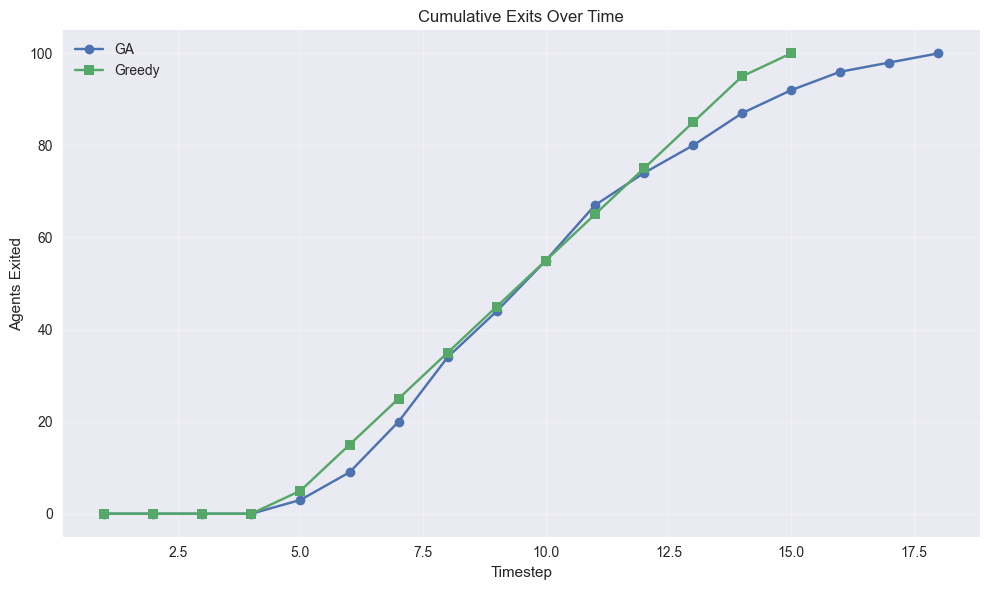

In [81]:
ga_times = moderate_ga_eval_agents.chromosome.path_time
greedy_times = moderate_greedy_eval.chromosome.path_time
plot_cumulative_exits(ga_times, greedy_times)

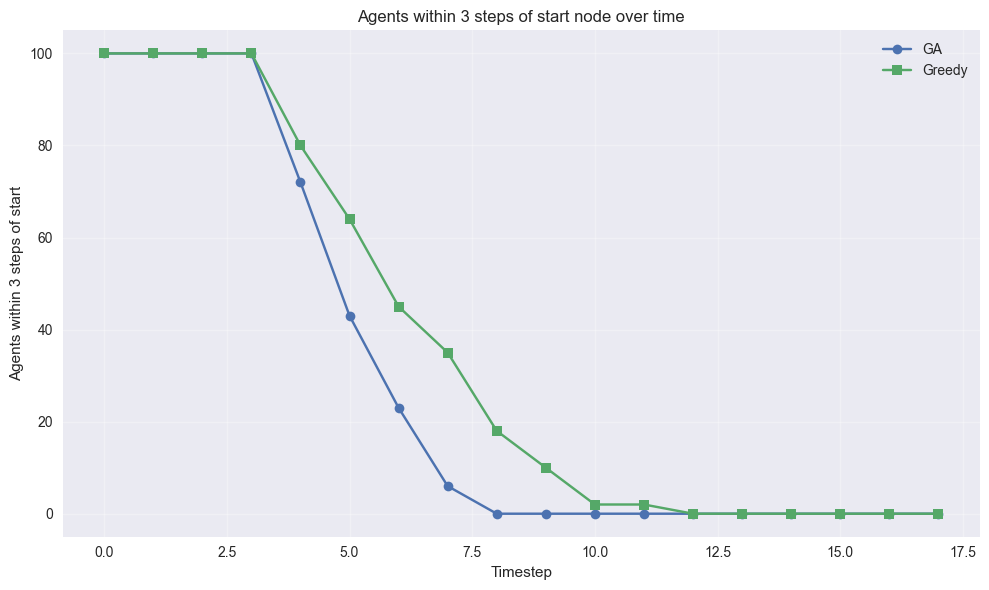

In [91]:
ga_agent_time_paths = moderate_ga_eval_agents.chromosome.get_timesteps()
greedy_agent_time_paths = moderate_greedy_eval.chromosome.get_timesteps()

plot_agents_within_x_steps(ga_agent_time_paths, greedy_agent_time_paths, 3)

In [82]:
hyperparams = {
    "crossover": 0.8,
    "mutation": 0.1,
    "epsilon": 0.8,
    "max_evolutions": 50,
    "survivor_method": 'elite_percentage',
    "tournament_size": None
}

params = {"congestion": True, "walking": False, "fitness": "max", "alpha": 0.8}

moderate_ga_solution_08, moderate_ga_eval_08 = simulate_ga_evacuation(
    city=moderate_city,
    num_agents=100,
    population_size=population_size+50,
    simulation_params=params,
    hyperparams=hyperparams,
    seed=algorithm_seeds[0],
    verbose=10
)

------------------------------------------------------------------------------------------------------------------------------------------------------
 City: moderate_city | Population size: 70 | Walking Speed: 2.0
------------------------------------------------------------------------------------------------------------------------------------------------------
Evolution    1 | best fit: 15.846 | avg fit: 18.950 | worst fit: 21.632 | avg path: 9.626 | congestion: 1.750 | exit use: 0.101 | diveristy: 0.745
Evolution   10 | best fit: 14.874 | avg fit: 18.709 | worst fit: 22.262 | avg path: 9.340 | congestion: 1.521 | exit use: 0.085 | diveristy: 0.695
Evolution   20 | best fit: 14.850 | avg fit: 18.000 | worst fit: 21.468 | avg path: 9.301 | congestion: 1.444 | exit use: 0.081 | diveristy: 0.656
Evolution   30 | best fit: 14.834 | avg fit: 18.569 | worst fit: 21.400 | avg path: 9.368 | congestion: 1.421 | exit use: 0.079 | diveristy: 0.603
Evolution   40 | best fit: 14.830 | avg fit: 1

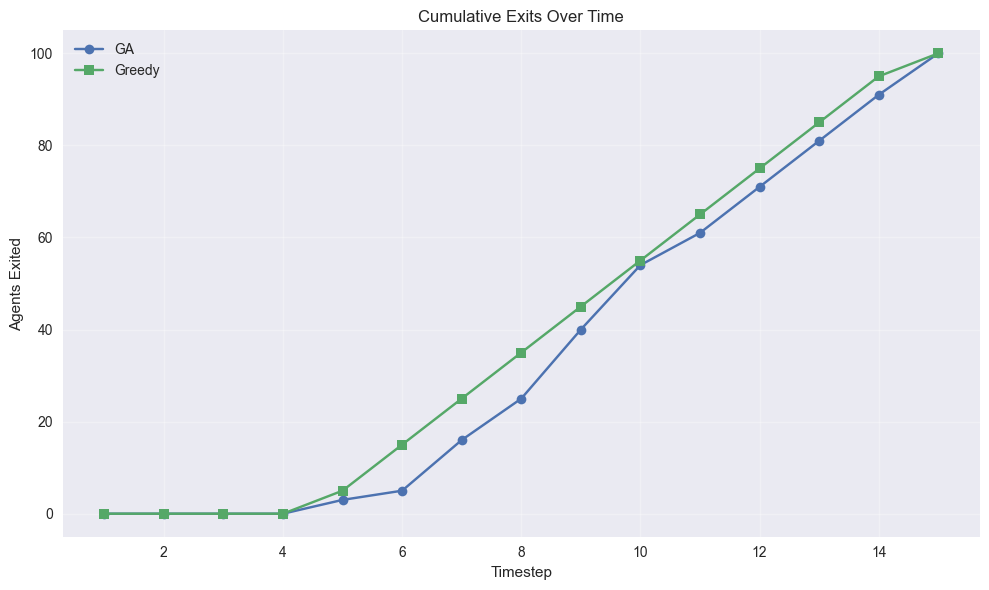

In [83]:
ga_08_times = moderate_ga_eval_08.chromosome.path_time
plot_cumulative_exits(ga_08_times, greedy_times)

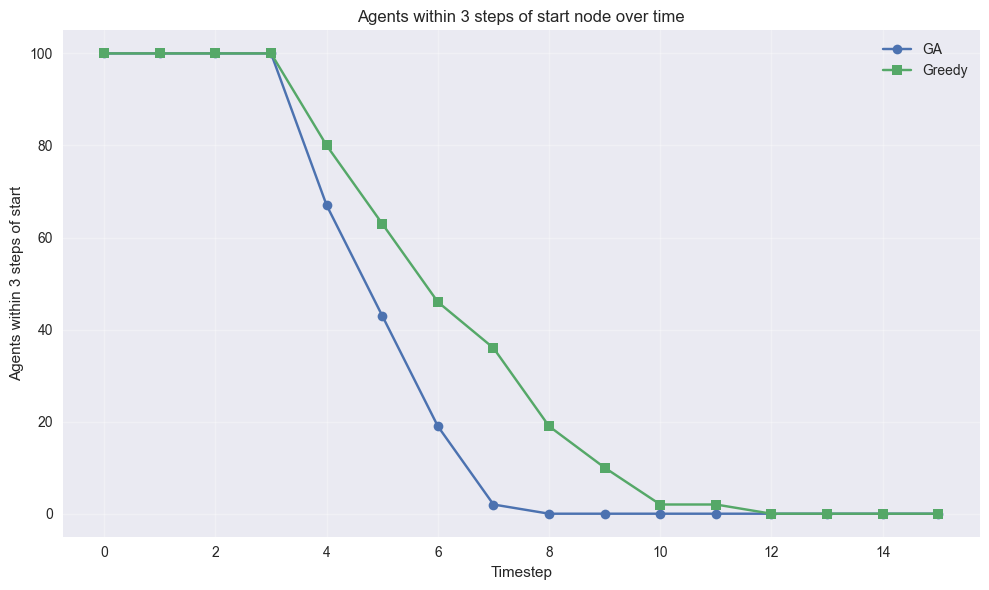

In [89]:
ga_agent_time_paths = moderate_ga_eval_08.chromosome.get_timesteps()
greedy_agent_time_paths = moderate_greedy_eval.chromosome.get_timesteps()

plot_agents_within_x_steps(ga_agent_time_paths, greedy_agent_time_paths, 3)

Greedy agents are stuck within 3 steps of their start until timestep 10, because the nearest exit is congested and they won't reroute
GA agents have almost entirely cleared that 3-step radius by timestep 7

So the argument becomes: greedy optimises for individual speed but creates collective immobility. In a static environment that's a wash — both finish at timestep 15. But in a dynamic environment like a fire, the greedy agents sitting congested near their start nodes for 6 extra timesteps are catastrophically vulnerable.

`Conclusion`

GA matches greedy on total evacuation time (both 15 timesteps) but achieves this through a fundamentally different strategy
Greedy agents cluster at nearest exits causing high congestion (84%) with large delays (4.05), GA spreads agents across exits reducing congestion (75%) and delay (1.44)
GA doubles exit utilisation (0.05 → 0.10), demonstrating genuine global optimisation vs individually optimal greedy routing
Greedy agents remain near start nodes significantly longer due to congestion — GA agents disperse faster despite taking longer paths
In a static environment this is a wash on total time, but in a dynamic environment (fire) greedy's collective immobility near start nodes creates significantly higher risk exposure
GA fitness consistently improved across 50 evolutions suggesting further gains are likely with more iterations and parameter tuning

The core finding you already have is strong:
Greedy routing is individually rational but collectively dangerous — agents cluster near start nodes, congest exits, and remain exposed for longer. GA routing sacrifices individual optimality for collective safety.